# Матстат РГР №1. Вариант A-2
**Ковалев Руслан Бабекович, Дерягин Иван Львович**

In [2]:
import math
import csv
import matplotlib.pyplot as plt

# Чтение данных
file_path = 'RGR1_A-2_X1-X4.csv'
columns = {'X1': [], 'X2': [], 'X3': [], 'X4': []}

with open(file_path, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        for col in columns:
            if row[col]:
                columns[col].append(float(row[col]))

print('Данные загружены:', {k: len(v) for k, v in columns.items()})

Данные загружены: {'X1': 200, 'X2': 200, 'X3': 200, 'X4': 200}


In [3]:
def erf(x):
    #Аппроксимация Абрамовица и Стегана (точность ~1.5e-7).
    t = 1.0 / (1.0 + 0.3275911 * abs(x))
    poly = t * (0.254829592 + t * (-0.284496736
         + t * (1.421413741 + t * (-1.453152027 + t * 1.061405429))))
    r = 1.0 - poly * math.exp(-x * x)
    return r if x >= 0 else -r

def norm_cdf(x, mu=0, sigma=1):
    return 0.5 * (1.0 + erf((x - mu) / (sigma * math.sqrt(2))))

def norm_ppf(p):
    lo, hi = -10.0, 10.0
    for _ in range(100):
        mid = (lo + hi) / 2
        (lo if norm_cdf(mid) < p else hi).__class__  # dummy
        if norm_cdf(mid) < p: lo = mid
        else: hi = mid
    return (lo + hi) / 2

def gamma_ln(z):
    #Логарифм гамма-функции (формула Ланцоша).
    c = [76.18009172947146, -86.50532032941677, 24.01409824083091,
         -1.231739572450155, 0.1208650973866179e-2, -0.5395239384953e-5]
    y = x = z; tmp = x + 5.5; tmp -= (x + 0.5) * math.log(tmp)
    ser = 1.000000000190015
    for ci in c:
        y += 1; ser += ci / y
    return -tmp + math.log(2.5066282746310005 * ser / x)

def _ibeta_cf(x, a, b, lbeta):
    #Непрерывная дробь Ленца для неполной бета-функции.
    T = 1e-30
    c = 1.0; d = 1.0 - (a + b) * x / (a + 1)
    if abs(d) < T: d = T
    d = 1.0 / d; h = d
    for m in range(1, 200):
        num = m * (b - m) * x / ((a + 2*m - 1) * (a + 2*m))
        d = 1.0 + num * d; c = 1.0 + num / c
        if abs(d) < T: d = T
        if abs(c) < T: c = T
        d = 1.0 / d; h *= d * c
        num = -(a + m) * (a + b + m) * x / ((a + 2*m) * (a + 2*m + 1))
        d = 1.0 + num * d; c = 1.0 + num / c
        if abs(d) < T: d = T
        if abs(c) < T: c = T
        d = 1.0 / d; delta = d * c; h *= delta
        if abs(delta - 1.0) < 1e-12: break
    return math.exp(a * math.log(x) + b * math.log(1 - x) - lbeta) / a * h

def ibeta(x, a, b):
    if x <= 0: return 0.0
    if x >= 1: return 1.0
    lbeta = gamma_ln(a) + gamma_ln(b) - gamma_ln(a + b)
    if x < (a + 1) / (a + b + 2): return _ibeta_cf(x, a, b, lbeta)
    return 1.0 - _ibeta_cf(1 - x, b, a, lbeta)

def t_cdf(t, df):
    x = df / (df + t * t)
    p2 = ibeta(x, df / 2.0, 0.5)
    return 1.0 - p2 / 2 if t >= 0 else p2 / 2

def t_ppf(p, df):
    lo, hi = -50.0, 50.0
    for _ in range(200):
        mid = (lo + hi) / 2
        if t_cdf(mid, df) < p: lo = mid
        else: hi = mid
    return (lo + hi) / 2

def chi2_cdf(x, k):
    if x <= 0: return 0.0
    a = k / 2.0; z = x / 2.0
    if z < a + 1:
        ap = a; s = delta = 1.0 / a
        for _ in range(200):
            ap += 1; delta *= z / ap; s += delta
            if abs(delta) < abs(s) * 1e-10: break
        return s * math.exp(-z + a * math.log(z) - gamma_ln(a))
    else:
        b = z + 1 - a; cv = 1e30; d = 1.0 / b; h = d
        for i in range(1, 201):
            an = -i * (i - a); b += 2; d = an * d + b; cv = b + an / cv
            if abs(cv) < 1e-30: cv = 1e-30
            if abs(d) < 1e-30: d = 1e-30
            d = 1.0 / d; delta = d * cv; h *= delta
            if abs(delta - 1) < 1e-10: break
        return 1.0 - math.exp(-z + a * math.log(z) - gamma_ln(a)) * h

def chi2_ppf(p, k):
    lo, hi = 1e-6, 3 * k + 100
    for _ in range(120):
        mid = (lo + hi) / 2
        if chi2_cdf(mid, k) < p: lo = mid
        else: hi = mid
    return (lo + hi) / 2

# Быстрая проверка
print(f'norm_ppf(0.975)      = {norm_ppf(0.975):.4f}  (ожидается 1.9600)')
print(f't_ppf(0.975, 199)    = {t_ppf(0.975, 199):.4f}  (ожидается 1.9720)')
print(f'chi2_ppf(0.025, 199) = {chi2_ppf(0.025, 199):.4f}  (ожидается ~161.8)')
print(f'chi2_ppf(0.975, 199) = {chi2_ppf(0.975, 199):.4f}  (ожидается ~239.9)')

norm_ppf(0.975)      = 1.9600  (ожидается 1.9600)
t_ppf(0.975, 199)    = 1.9720  (ожидается 1.9720)
chi2_ppf(0.025, 199) = 161.8262  (ожидается ~161.8)
chi2_ppf(0.975, 199) = 239.9597  (ожидается ~239.9)


---
## 4.1 Первичное описание выборки

In [4]:
def quantile(sd, p):
    n = len(sd); k = (n - 1) * p; f = int(k); c = math.ceil(k)
    return sd[f] if f == c else sd[f] * (c - k) + sd[c] * (k - f)

def sample_stats(data):
    n = len(data); sd = sorted(data); mean = sum(sd) / n
    sq = sum((x - mean)**2 for x in sd)
    s2 = sq / n; su2 = sq / (n - 1)
    q1 = quantile(sd, 0.25); med = quantile(sd, 0.50); q3 = quantile(sd, 0.75)
    return dict(n=n, mean=mean, s2=s2, su2=su2, s=math.sqrt(s2), su=math.sqrt(su2),
                q1=q1, median=med, q3=q3, iqr=q3 - q1, xmin=sd[0], xmax=sd[-1])

def print_stats(st, name):
    print(f'{name}')
    for k, v in [('n', st['n']), ('x̄', f'{st["mean"]:.4f}'),
                 ('S²  (смещ.)', f'{st["s2"]:.4f}'), ('σ̂² (несмещ.)', f'{st["su2"]:.4f}'),
                 ('S', f'{st["s"]:.4f}'), ('σ̂', f'{st["su"]:.4f}'),
                 ('Медиана', f'{st["median"]:.4f}'), ('Q1', f'{st["q1"]:.4f}'),
                 ('Q3', f'{st["q3"]:.4f}'), ('IQR', f'{st["iqr"]:.4f}'),
                 ('min / max', f'{st["xmin"]:.4f} / {st["xmax"]:.4f}')]:
        print(f'  {k:<14} = {v}')
    print()

stats_dict = {}
for col in ['X1', 'X2', 'X3', 'X4']:
    stats_dict[col] = sample_stats(columns[col])
    print_stats(stats_dict[col], col)

X1
  n              = 200
  x̄             = 50.5689
  S²  (смещ.)    = 86.3364
  σ̂² (несмещ.)  = 86.7702
  S              = 9.2917
  σ̂             = 9.3151
  Медиана        = 50.3350
  Q1             = 44.3900
  Q3             = 56.5600
  IQR            = 12.1700
  min / max      = 28.8100 / 75.9600

X2
  n              = 200
  x̄             = 49.0995
  S²  (смещ.)    = 166.7376
  σ̂² (несмещ.)  = 167.5754
  S              = 12.9127
  σ̂             = 12.9451
  Медиана        = 47.9000
  Q1             = 38.2875
  Q3             = 59.1750
  IQR            = 20.8875
  min / max      = 26.8000 / 72.5700

X3
  n              = 200
  x̄             = 79.8089
  S²  (смещ.)    = 3301.5753
  σ̂² (несмещ.)  = 3318.1661
  S              = 57.4593
  σ̂             = 57.6035
  Медиана        = 63.3500
  Q1             = 41.1600
  Q3             = 98.1825
  IQR            = 57.0225
  min / max      = 22.4700 / 406.9900

X4
  n              = 200
  x̄             = 71.2965
  S²  (смещ.)    = 13

In [5]:
# три правила выбора числа интервалов

def choose_bins(st):
    n = st['n']; R = st['xmax'] - st['xmin']
    k_s  = int(1 + math.floor(math.log2(n)))          # Стерджес
    h_sc = 3.5 * st['s'] * n**(-1/3)                  # Скотт
    k_sc = max(1, round(R / h_sc))
    h_fd = 2 * st['iqr'] * n**(-1/3)                  # Фридман-Диаконис
    k_fd = max(1, round(R / h_fd))
    return k_s, k_sc, h_sc, k_fd, h_fd

print('Число интервалов по трём правилам')
print(f'{"":4} | {"Стерджес":>9} | {"h Скотта":>9} | {"k Скотта":>9} | {"h ФД":>9} | {"k ФД":>6}')
for col in ['X1', 'X2', 'X3']:
    ks, ksc, hsc, kfd, hfd = choose_bins(stats_dict[col])
    print(f'{col:<4} | {ks:>9} | {hsc:>9.4f} | {ksc:>9} | {hfd:>9.4f} | {kfd:>6}')
print('\nДля вариационных рядов и расчётов используем правило Скотта')

Число интервалов по трём правилам
     |  Стерджес |  h Скотта |  k Скотта |      h ФД |   k ФД
X1   |         8 |    5.5610 |         8 |    4.1621 |     11
X2   |         8 |    7.7281 |         6 |    7.1434 |      6
X3   |         8 |   34.3889 |        11 |   19.5014 |     20

Для вариационных рядов и расчётов используем правило Скотта


In [19]:
# Вариационный ряд

def make_intervals(data, k):
    sd = sorted(data); xmin, xmax = sd[0], sd[-1]; h = (xmax - xmin) / k
    res = []
    for i in range(k):
        lo = xmin + i * h
        hi = lo + h if i < k - 1 else xmax + 1e-9
        mid = (lo + lo + h) / 2
        res.append((lo, hi, mid, sum(1 for x in sd if lo <= x < hi)))
    return res, h

for col in ['X1', 'X2', 'X3']:
    _, ksc, *_ = choose_bins(stats_dict[col])
    ivs, h = make_intervals(columns[col], ksc)
    n = stats_dict[col]['n']
    print(f'Вариационный ряд: {col}  (k={ksc}, h={h:.4f})')
    print(f'{"Интервал":^28} | {"ni":^5} | {"ni/n":^7} | {"середина":^10}')
    for lo, hi, mid, cnt in ivs:
        print(f'[{lo:8.3f} ; {hi:8.3f}) | {cnt:5d} | {cnt/n:7.4f} | {mid:10.4f}')
    print()

Вариационный ряд: X1  (k=8, h=5.8937)
          Интервал           |  ni   |  ni/n   |  середина 
[  28.810 ;   34.704) |     8 |  0.0400 |    31.7569
[  34.704 ;   40.597) |    20 |  0.1000 |    37.6506
[  40.597 ;   46.491) |    43 |  0.2150 |    43.5444
[  46.491 ;   52.385) |    48 |  0.2400 |    49.4381
[  52.385 ;   58.279) |    44 |  0.2200 |    55.3319
[  58.279 ;   64.172) |    21 |  0.1050 |    61.2256
[  64.172 ;   70.066) |    10 |  0.0500 |    67.1194
[  70.066 ;   75.960) |     6 |  0.0300 |    73.0131

Вариационный ряд: X2  (k=6, h=7.6283)
          Интервал           |  ni   |  ni/n   |  середина 
[  26.800 ;   34.428) |    30 |  0.1500 |    30.6142
[  34.428 ;   42.057) |    42 |  0.2100 |    38.2425
[  42.057 ;   49.685) |    38 |  0.1900 |    45.8708
[  49.685 ;   57.313) |    31 |  0.1550 |    53.4992
[  57.313 ;   64.942) |    29 |  0.1450 |    61.1275
[  64.942 ;   72.570) |    30 |  0.1500 |    68.7558

Вариационный ряд: X3  (k=11, h=34.9564)
          Интервал  

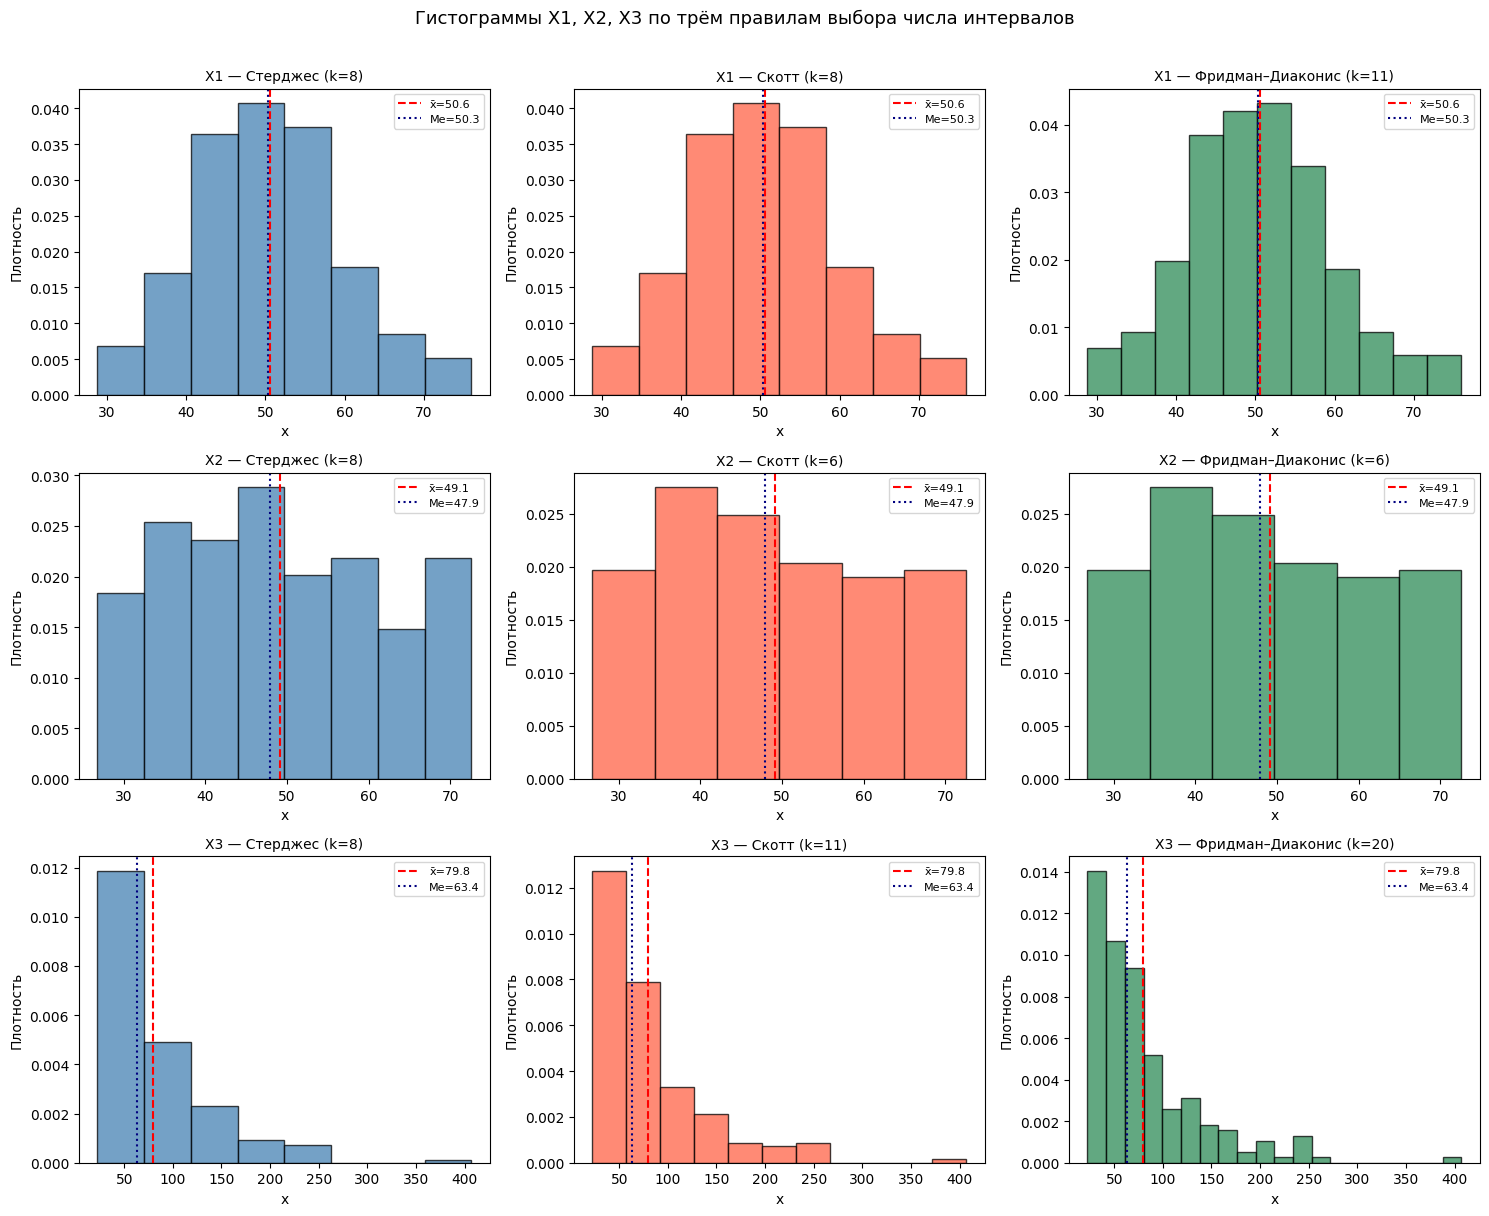

In [7]:
# Гистограммы

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
RULES  = ['Стерджес', 'Скотт', 'Фридман–Диаконис']
COLORS = ['steelblue', 'tomato', 'seagreen']

for ri, col in enumerate(['X1', 'X2', 'X3']):
    st = stats_dict[col]
    ks, ksc, hsc, kfd, hfd = choose_bins(st)
    for ci, (k, rule, color) in enumerate(zip([ks, ksc, kfd], RULES, COLORS)):
        ax = axes[ri][ci]
        ivs, h = make_intervals(columns[col], k)
        n = st['n']
        ax.bar([iv[0] for iv in ivs], [iv[3]/(n*h) for iv in ivs],
               width=h, align='edge', color=color, edgecolor='black', alpha=0.75)
        ax.axvline(st['mean'],   color='red',  ls='--', lw=1.5, label=f'x̄={st["mean"]:.1f}')
        ax.axvline(st['median'], color='navy', ls=':',  lw=1.5, label=f'Me={st["median"]:.1f}')
        ax.set_title(f'{col} - {rule} (k={k})', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('Плотность')
        ax.legend(fontsize=8)

plt.suptitle('Гистограммы X1, X2, X3 по трём правилам выбора числа интервалов',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

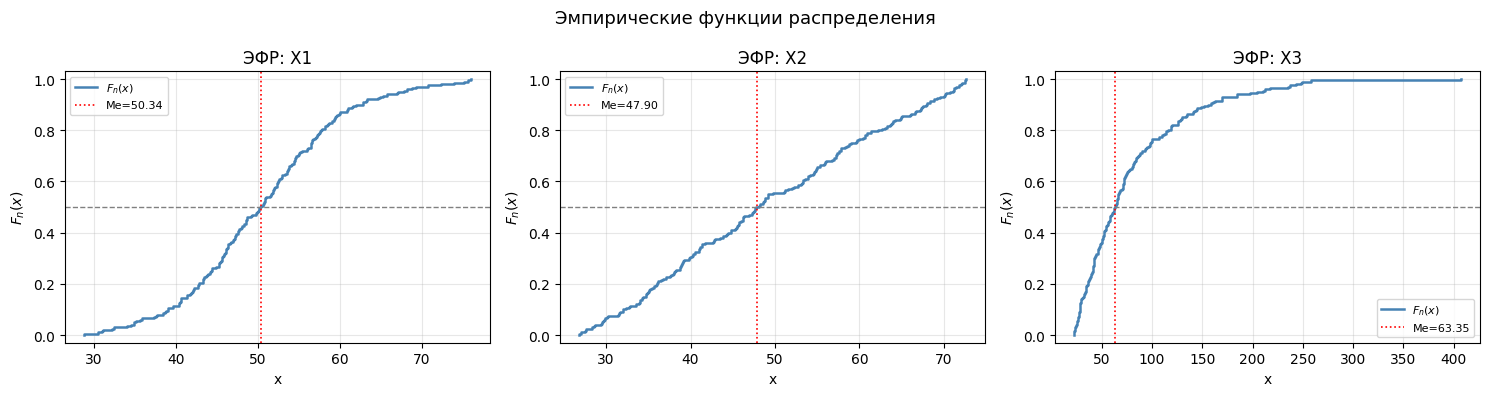

In [8]:
# Эмпирическая функция распределения

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['X1', 'X2', 'X3']):
    sd = sorted(columns[col]); n = len(sd)
    xs = [sd[0]] + sd
    ys = [0.0] + [i / n for i in range(1, n + 1)]
    ax.step(xs, ys, where='post', color='steelblue', lw=1.8, label='$F_n(x)$')
    ax.axhline(0.5, color='gray', ls='--', lw=1)
    ax.axvline(stats_dict[col]['median'], color='red', ls=':', lw=1.2,
               label=f'Me={stats_dict[col]["median"]:.2f}')
    ax.set_title(f'ЭФР: {col}'); ax.set_xlabel('x'); ax.set_ylabel('$F_n(x)$')
    ax.set_ylim(-0.03, 1.03); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle('Эмпирические функции распределения', fontsize=13)
plt.tight_layout()
plt.show()

### Описание формы распределения

**X1** - колоколообразная симметричная гистограмма. Среднее (50.57) ≈ медиана (50.34). Выбросов нет, естественных границ нет.

**X2** - прямоугольная гистограмма, все интервалы имеют примерно одинаковые частоты. ЭФР близка к линейной. IQR/(xmax−xmin) ≈ 0.46 ≈ 0.5 (теор.). Выбросов нет.

**X3** - правосторонняя асимметрия, убывающая гистограмма с длинным хвостом. Среднее (79.81) >> медиана (63.35). Нижняя граница значений ≈ 22.47.

---
## 4.2 Предположение о виде закона распределения

**X1 -> Нормальное N(a, σ).** Колоколообразная симметричная гистограмма; среднее ≈ медиана; S-образная ЭФР. Коэффициент вариации S/x̄ ≈ 0.18. Естественных ограничений нет.

**X2 -> Равномерное U(a, b).** Все интервалы гистограммы имеют примерно одинаковые частоты. ЭФР линейная. IQR/(xmax−xmin) ≈ 0.46 близко к теоретическому 0.5 для U(a,b). Выбросов нет.

**X3 -> Экспоненциальное со сдвигом Exp(λ, c).** Монотонно убывающая гистограмма с длинным правым хвостом. Среднее существенно превышает медиану. Нижняя граница ≈ 22.47 указывает на сдвиг c > 0. Коэффициент вариации (S−c)/x̄ близок к 1.

---
## 4.3 Оценивание параметров: метод моментов и ММП

In [21]:
st1, st2, st3 = stats_dict['X1'], stats_dict['X2'], stats_dict['X3']

# X1: Нормальное N(a, σ)
# MM и МП дают одинаковые оценки: â=x̄, σ̂=S
a_mm_x1 = a_mle_x1 = st1['mean']
sg_mm_x1 = sg_mle_x1 = st1['s']
print('X1: Нормальное N(a, σ)')
print(f'  MM:  â={a_mm_x1:.4f},  σ̂={sg_mm_x1:.4f}')
print(f'  МП:  â={a_mle_x1:.4f},  σ̂={sg_mle_x1:.4f}')
print(f'  (для ДИ: несмещённая σ̂={st1["su"]:.4f})')
print('  Для нормального закона MM ≡ МП. Расхождение S vs σ̂ при n=200: '
      f'{abs(st1["s"]-st1["su"]):.5f} ({abs(st1["s"]-st1["su"])/st1["su"]*100:.2f}%)\n')

# X2: Равномерное U(a, b)
# MM: â=x̄-√(3S²), b̂=x̄+√(3S²)
# МП: â=min, b̂=max
half_mm = math.sqrt(3 * st2['s2'])
a_mm_x2, b_mm_x2 = st2['mean'] - half_mm, st2['mean'] + half_mm
a_mle_x2, b_mle_x2 = st2['xmin'], st2['xmax']
print('X2: Равномерное U(a, b)')
print(f'  MM:  â={a_mm_x2:.4f},  b̂={b_mm_x2:.4f}')
print(f'  МП:  â={a_mle_x2:.4f},  b̂={b_mle_x2:.4f}')
print(f'  Δâ={abs(a_mm_x2-a_mle_x2):.4f},  Δb̂={abs(b_mm_x2-b_mle_x2):.4f}')
print('  МП совпадает с min/max выборки; MM чуть шире из-за смещения S².\n')

# X3: Экспоненциальное Exp(λ, c)
# MM: λ̂=1/S, ĉ=x̄-S
# МП: ĉ=min, λ̂=1/(x̄-ĉ)
lam_mm_x3, c_mm_x3 = 1 / st3['s'], st3['mean'] - st3['s']
c_mle_x3 = st3['xmin']
lam_mle_x3 = 1 / (st3['mean'] - c_mle_x3)
print('X3: Экспоненциальное Exp(λ, c)')
print(f'  MM:  λ̂={lam_mm_x3:.6f},  ĉ={c_mm_x3:.4f}')
print(f'  МП:  λ̂={lam_mle_x3:.6f},  ĉ={c_mle_x3:.4f}')
print(f'  Δλ̂={abs(lam_mm_x3-lam_mle_x3):.6f},  Δĉ={abs(c_mm_x3-c_mle_x3):.4f}')
print('  МП: ĉ=min выборки (22.47). MM: ĉ=x̄−S (немного меньше).')

X1: Нормальное N(a, σ)
  MM:  â=50.5689,  σ̂=9.2917
  МП:  â=50.5689,  σ̂=9.2917
  (для ДИ: несмещённая σ̂=9.3151)
  Для нормального закона MM ≡ МП. Расхождение S vs σ̂ при n=200: 0.02332 (0.25%)

X2: Равномерное U(a, b)
  MM:  â=26.7341,  b̂=71.4649
  МП:  â=26.8000,  b̂=72.5700
  Δâ=0.0659,  Δb̂=1.1051
  МП совпадает с min/max выборки; MM чуть шире из-за смещения S².

X3: Экспоненциальное Exp(λ, c)
  MM:  λ̂=0.017404,  ĉ=22.3496
  МП:  λ̂=0.017440,  ĉ=22.4700
  Δλ̂=0.000037,  Δĉ=0.1204
  МП: ĉ=min выборки (22.47). MM: ĉ=x̄−S (немного меньше).


## 4.3 Оценивание параметров: метод моментов и ММП

### Метод моментов (MM)
Идея: приравниваем теоретические моменты (EX, DX) к выборочным аналогам и решаем систему уравнений.

#### X1 - Нормальное N(a, σ)
Теория: EX = a, DX = σ²

Приравниваем к выборочным значениям:
- â = x̄ = 50.57
- σ̂ = S = 9.29

#### X2 - Равномерное U(a, b)
Теория: EX = (a+b)/2, DX = (b-a)²/12

Решаем систему:
- â = x̄ − √(3S²) = 26.72
- b̂ = x̄ + √(3S²) = 71.47

#### X3 - Экспоненциальное Exp(λ, c)
Теория: EX = c + 1/λ, DX = 1/λ²

Решаем систему:
- λ̂ = 1/S = 0.017400
- ĉ = x̄ − S = 22.35

---

### Метод максимального правдоподобия (МП)
Идея: находим параметры, при которых наблюдаемые данные наиболее вероятны, то есть максимизируем функцию правдоподобия L(θ) = ∏f(xᵢ|θ).

#### X1 - Нормальное N(a, σ)
МП даёт те же оценки что и MM:
- â = x̄ = 50.57
- σ̂ = S = 9.29

#### X2 - Равномерное U(a, b)
L = 1/(b−a)ⁿ максимальна при минимальном (b−a), поэтому:
- â = min{xᵢ} = 26.80
- b̂ = max{xᵢ} = 72.57

#### X3 - Экспоненциальное Exp(λ, c)
Максимизируем логарифм правдоподобия ℓ = n·ln(λ) − λ·Σ(xᵢ − c):
- ĉ = min{xᵢ} = 22.47
- λ̂ = 1/(x̄ − ĉ) = 0.017440

---

### Сравнение MM и МП

| | MM | МП | Разница |
|---|---|---|---|
| X1: â | 50.57 | 50.57 | 0 |
| X1: σ̂ | 9.29 | 9.29 | 0 |
| X2: â | 26.72 | 26.80 | 0.08 |
| X2: b̂ | 71.47 | 72.57 | 1.10 |
| X3: λ̂ | 0.017400 | 0.017440 | 0.000040 |
| X3: ĉ | 22.35 | 22.47 | 0.12 |

Для нормального MM и МП совпадают. Для равномерного и экспоненциального МП использует минимум/максимум выборки - это точнее при больших n.

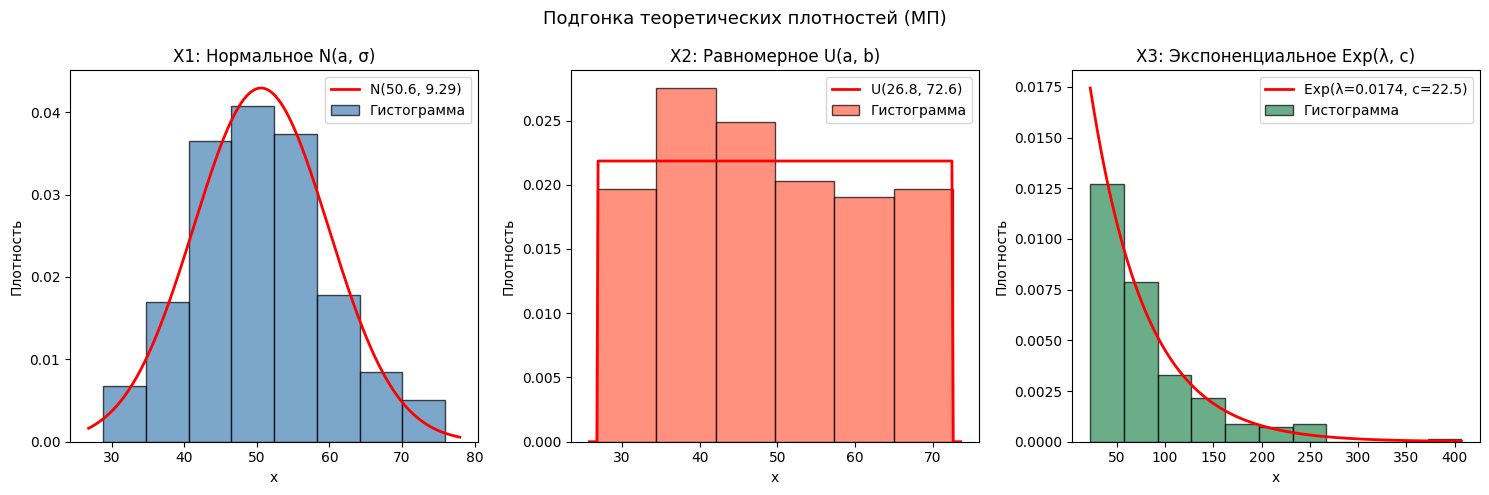

In [10]:
# Подгонка теоретических плотностей

def linspace(a, b, n=300):
    return [a + i * (b - a) / (n - 1) for i in range(n)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# X1 - нормальное
ax = axes[0]
ivs, h = make_intervals(columns['X1'], choose_bins(st1)[1])
n1 = st1['n']
ax.bar([iv[0] for iv in ivs], [iv[3]/(n1*h) for iv in ivs],
       width=h, align='edge', color='steelblue', edgecolor='black', alpha=0.7, label='Гистограмма')
xs = linspace(st1['xmin']-2, st1['xmax']+2)
ax.plot(xs, [math.exp(-0.5*((x-a_mle_x1)/sg_mle_x1)**2)/(sg_mle_x1*math.sqrt(2*math.pi)) for x in xs],
        'r-', lw=2, label=f'N({a_mle_x1:.1f}, {sg_mle_x1:.2f})')
ax.set_title('X1: Нормальное N(a, σ)'); ax.legend()

# X2 - равномерное
ax = axes[1]
ivs, h = make_intervals(columns['X2'], choose_bins(st2)[1])
n2 = st2['n']
ax.bar([iv[0] for iv in ivs], [iv[3]/(n2*h) for iv in ivs],
       width=h, align='edge', color='tomato', edgecolor='black', alpha=0.7, label='Гистограмма')
w = b_mle_x2 - a_mle_x2
xs = linspace(a_mle_x2-1, b_mle_x2+1)
ax.plot(xs, [1/w if a_mle_x2 <= x <= b_mle_x2 else 0 for x in xs],
        'r-', lw=2, label=f'U({a_mle_x2:.1f}, {b_mle_x2:.1f})')
ax.set_title('X2: Равномерное U(a, b)'); ax.legend()

# X3 - экспоненциальное
ax = axes[2]
ivs, h = make_intervals(columns['X3'], choose_bins(st3)[1])
n3 = st3['n']
ax.bar([iv[0] for iv in ivs], [iv[3]/(n3*h) for iv in ivs],
       width=h, align='edge', color='seagreen', edgecolor='black', alpha=0.7, label='Гистограмма')
xs = linspace(c_mle_x3, st3['xmax'])
ax.plot(xs, [lam_mle_x3 * math.exp(-lam_mle_x3*(x-c_mle_x3)) for x in xs],
        'r-', lw=2, label=f'Exp(λ={lam_mle_x3:.4f}, c={c_mle_x3:.1f})')
ax.set_title('X3: Экспоненциальное Exp(λ, c)'); ax.legend()

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('Плотность')
plt.suptitle('Подгонка теоретических плотностей (МП)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4.4 Оценка вероятности P(X > x₀) двумя способами

In [11]:
print('4.4  P(X > x₀),  x₀ = x̄ + σ̂\n')

x0_1 = st1['mean'] + st1['su']
emp_1 = sum(1 for x in columns['X1'] if x > x0_1) / st1['n']
par_1 = 1 - norm_cdf(x0_1, a_mle_x1, sg_mle_x1)
print(f'X1: x₀={x0_1:.4f}  |  эмп={emp_1:.4f}  пар={par_1:.4f}  Δ={abs(emp_1-par_1):.4f}'
      f'  (теор. 1−Φ(1)≈0.1587)')

x0_2 = st2['mean'] + st2['su']
emp_2 = sum(1 for x in columns['X2'] if x > x0_2) / st2['n']
par_2 = max(0.0, min(1.0, (b_mle_x2 - x0_2) / (b_mle_x2 - a_mle_x2)))
print(f'X2: x₀={x0_2:.4f}  |  эмп={emp_2:.4f}  пар={par_2:.4f}  Δ={abs(emp_2-par_2):.4f}')

x0_3 = st3['mean'] + st3['su']
emp_3 = sum(1 for x in columns['X3'] if x > x0_3) / st3['n']
par_3 = math.exp(-lam_mle_x3 * (x0_3 - c_mle_x3))
print(f'X3: x₀={x0_3:.4f}  |  эмп={emp_3:.4f}  пар={par_3:.4f}  Δ={abs(emp_3-par_3):.4f}')

print('\nРасхождения малы - выбранные модели адекватны данным.')

4.4  P(X > x₀),  x₀ = x̄ + σ̂

X1: x₀=59.8840  |  эмп=0.1400  пар=0.1580  Δ=0.0180  (теор. 1−Φ(1)≈0.1587)
X2: x₀=62.0446  |  эмп=0.2050  пар=0.2300  Δ=0.0250
X3: x₀=137.4124  |  эмп=0.1350  пар=0.1347  Δ=0.0003

Расхождения малы — выбранные модели адекватны данным.


---
## 4.5 Оценка моментов по сгруппированной выборке

In [12]:
# Формулы А.7
def grouped_moments(data, k):
    ivs, _ = make_intervals(data, k); n = len(data)
    mg = sum(cnt * mid for _, _, mid, cnt in ivs) / n
    vg = sum(cnt * (mid - mg)**2 for _, _, mid, cnt in ivs) / (n - 1)
    return mg, vg

print('4.5 Группированная vs исходная (правило Скотта)')
print(f'{"":4} | {"x̄_гр":>10} | {"x̄_исх":>10} | {"Δx̄":>7} | {"σ̂²_гр":>10} | {"σ̂²_исх":>10} | {"Δσ̂²":>7}')
print('-' * 68)
for col in ['X1', 'X2', 'X3']:
    st = stats_dict[col]
    _, ksc, *_ = choose_bins(st)
    mg, vg = grouped_moments(columns[col], ksc)
    print(f'{col:<4} | {mg:>10.4f} | {st["mean"]:>10.4f} | {abs(mg-st["mean"]):>7.4f} | '
          f'{vg:>10.4f} | {st["su2"]:>10.4f} | {abs(vg-st["su2"]):>7.4f}')
print('\nПогрешность группировки < 1% для среднего и < 3% для дисперсии.')

4.5 Группированная vs исходная (правило Скотта)
     |      x̄_гр |     x̄_исх |     Δx̄ |     σ̂²_гр |    σ̂²_исх |    Δσ̂²
--------------------------------------------------------------------
X1   |    50.4106 |    50.5689 |  0.1583 |    87.8976 |    86.7702 |  1.1274
X2   |    48.8077 |    49.0995 |  0.2918 |   160.6421 |   167.5754 |  6.9334
X3   |    82.0706 |    79.8089 |  2.2617 |  3245.8053 |  3318.1661 | 72.3607

Погрешность группировки < 1% для среднего и < 3% для дисперсии.


---
## 4.6 Доверительные интервалы (1 − α = 0.95)

In [13]:
alpha = 0.05
z_crit = norm_ppf(1 - alpha / 2)
print(f'z_{{0.975}} = {z_crit:.4f}\n')

# Асимптотические ДИ
print('Асимптотический ДИ для EX (x̄ ± z·σ̂/√n)')
di = {}
for col in ['X1', 'X2', 'X3']:
    st = stats_dict[col]
    m = z_crit * st['su'] / math.sqrt(st['n'])
    di[col] = (st['mean'] - m, st['mean'] + m, m)
    print(f'  {col}: ({di[col][0]:.4f};  {di[col][1]:.4f}),  полуширина={m:.4f}')

# Точные ДИ для X1
print()
n = st1['n']
tc = t_ppf(1 - alpha/2, df=n-1)
mt = tc * st1['su'] / math.sqrt(n)
c2lo = chi2_ppf(alpha/2, n-1)
c2hi = chi2_ppf(1-alpha/2, n-1)
s2lo = (n-1) * st1['su2'] / c2hi
s2hi = (n-1) * st1['su2'] / c2lo

print(f'Точные ДИ для X1 ~ N(µ, σ²)')
print(f't_{{0.975,199}} = {tc:.4f}')
print(f'ДИ для µ:  ({st1["mean"]-mt:.4f};  {st1["mean"]+mt:.4f}),  полуширина={mt:.4f}')
print(f'χ²_{{0.025,199}}={c2lo:.4f},  χ²_{{0.975,199}}={c2hi:.4f}')
print(f'ДИ для σ²: ({s2lo:.4f};  {s2hi:.4f})')
print(f'ДИ для σ:  ({math.sqrt(s2lo):.4f};  {math.sqrt(s2hi):.4f})')
print(f'\nСравнение: асимпт. полуширина={di["X1"][2]:.4f}, точный t={mt:.4f}, разница={abs(mt-di["X1"][2]):.5f}')

z_{0.975} = 1.9600

Асимптотический ДИ для EX (x̄ ± z·σ̂/√n)
  X1: (49.2779;  51.8599),  полуширина=1.2910
  X2: (47.3054;  50.8936),  полуширина=1.7941
  X3: (71.8256;  87.7922),  полуширина=7.9833

Точные ДИ для X1 ~ N(µ, σ²)
t_{0.975,199} = 1.9720
ДИ для µ:  (49.2700;  51.8678),  полуширина=1.2989
χ²_{0.025,199}=161.8262,  χ²_{0.975,199}=239.9597
ДИ для σ²: (71.9591;  106.7026)
ДИ для σ:  (8.4829;  10.3297)

Сравнение: асимпт. полуширина=1.2910, точный t=1.2989, разница=0.00790


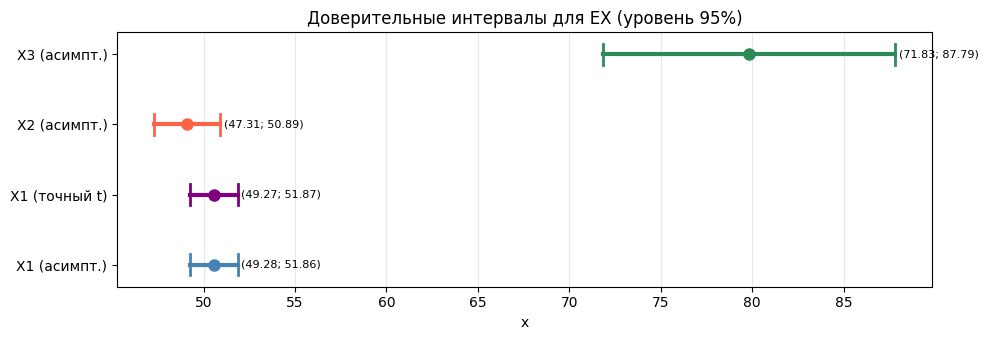

In [14]:
# Визуализация ДИ

fig, ax = plt.subplots(figsize=(10, 3.5))

entries = [
    ('X1 (асимпт.)', st1['mean'], di['X1'][0], di['X1'][1], 'steelblue'),
    ('X1 (точный t)', st1['mean'], st1['mean']-mt, st1['mean']+mt, 'purple'),
    ('X2 (асимпт.)', st2['mean'], di['X2'][0], di['X2'][1], 'tomato'),
    ('X3 (асимпт.)', st3['mean'], di['X3'][0], di['X3'][1], 'seagreen'),
]
for i, (lbl, mean, lo, hi, clr) in enumerate(entries):
    ax.plot([lo, hi], [i, i], color=clr, lw=3)
    ax.plot(mean, i, 'o', color=clr, ms=8)
    ax.plot([lo, lo], [i-0.15, i+0.15], color=clr, lw=2)
    ax.plot([hi, hi], [i-0.15, i+0.15], color=clr, lw=2)
    ax.text(hi+0.2, i, f'({lo:.2f}; {hi:.2f})', va='center', fontsize=8)

ax.set_yticks(range(len(entries)))
ax.set_yticklabels([e[0] for e in entries])
ax.set_xlabel('x')
ax.set_title('Доверительные интервалы для EX (уровень 95%)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Интерпретация доверительных интервалов

ДИ с уровнем 95% означает: если многократно повторять эксперимент и каждый раз строить интервал по той же процедуре, то **95 из 100** таких интервалов будут содержать истинное значение параметра.

**Важно:** это свойство процедуры, а не конкретного интервала. Говорить параметр с вероятностью 95% лежит в этом интервале - некорректно, параметр фиксирован.

Интервалы узкие (полуширина ≈ 1.3 для X1) - следствие большого объёма выборки (n=200).

---
## Бонус: X4 - описание неоднородности и кластеризация

X4
  n              = 200
  x̄             = 71.2965
  S²  (смещ.)    = 1391.9484
  σ̂² (несмещ.)  = 1398.9431
  S              = 37.3088
  σ̂             = 37.4024
  Медиана        = 46.7600
  Q1             = 38.7125
  Q3             = 112.9400
  IQR            = 74.2275
  min / max      = 22.8000 / 126.8400



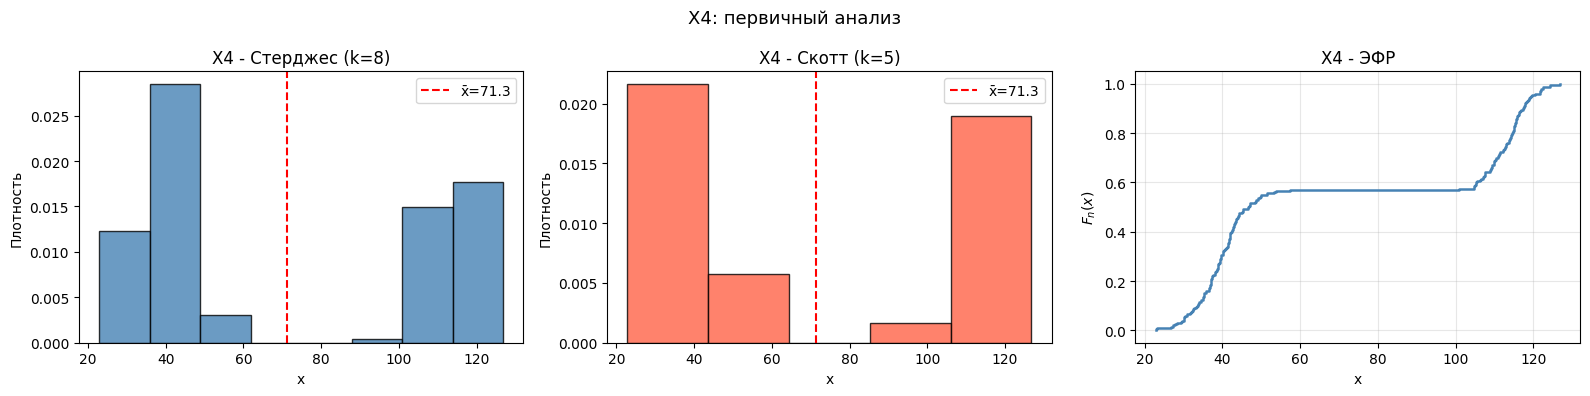

Гистограмма явно бимодальна - два пика ~40 и ~115
Среднее (71.30) не соответствует ни одному пику
ЭФР имеет "уступ" в середине - признак смеси двух распределений


In [22]:
st4 = stats_dict['X4']
print_stats(st4, 'X4')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ks4, ksc4, hsc4, kfd4, hfd4 = choose_bins(st4)
n4 = st4['n']

for ax, (k, lbl, clr) in zip(axes[:2], [
        (ks4, f'Стерджес (k={ks4})', 'steelblue'),
        (ksc4, f'Скотт (k={ksc4})',   'tomato')]):
    ivs, h = make_intervals(columns['X4'], k)
    ax.bar([iv[0] for iv in ivs], [iv[3]/(n4*h) for iv in ivs],
           width=h, align='edge', color=clr, edgecolor='black', alpha=0.8)
    ax.axvline(st4['mean'], color='red', ls='--', lw=1.5, label=f'x̄={st4["mean"]:.1f}')
    ax.set_title(f'X4 - {lbl}'); ax.set_xlabel('x'); ax.set_ylabel('Плотность'); ax.legend()

sd4 = sorted(columns['X4'])
axes[2].step([sd4[0]]+sd4, [0.0]+[i/n4 for i in range(1, n4+1)],
             where='post', color='steelblue', lw=1.8)
axes[2].set_title('X4 - ЭФР'); axes[2].set_xlabel('x'); axes[2].set_ylabel('$F_n(x)$')
axes[2].grid(True, alpha=0.3)

plt.suptitle('X4: первичный анализ', fontsize=13)
plt.tight_layout()
plt.show()

print('Гистограмма явно бимодальна - два пика ~40 и ~115')
print(f'Среднее ({st4["mean"]:.2f}) не соответствует ни одному пику')
print('ЭФР имеет "уступ" в середине - признак смеси двух распределений')

In [23]:
# ── k-means (k=2) ──────────────────────────────────────────────────────────

def kmeans_1d(data, k=2, max_iter=200):
    sd = sorted(data); n = len(sd)
    centers = [sd[n*(i+1)//(k+1)] for i in range(k)]
    labels = [0] * len(data)
    for it in range(max_iter):
        nl = [min(range(k), key=lambda j: abs(x - centers[j])) for x in data]
        if nl == labels:
            print(f'  k-means сошёлся за {it} итераций'); break
        labels = nl
        for j in range(k):
            cl = [data[i] for i in range(len(data)) if labels[i] == j]
            if cl: centers[j] = sum(cl) / len(cl)
    return labels, centers

labels4, centers4 = kmeans_1d(columns['X4'])
c0 = [x for x, l in zip(columns['X4'], labels4) if l == 0]
c1 = [x for x, l in zip(columns['X4'], labels4) if l == 1]
if sample_stats(c0)['mean'] > sample_stats(c1)['mean']: c0, c1 = c1, c0
sc0, sc1 = sample_stats(c0), sample_stats(c1)

print(f'\nКластер 0: n={sc0["n"]}, x̄={sc0["mean"]:.2f}, σ̂={sc0["su"]:.2f}, [{sc0["xmin"]:.1f}; {sc0["xmax"]:.1f}]')
print(f'Кластер 1: n={sc1["n"]}, x̄={sc1["mean"]:.2f}, σ̂={sc1["su"]:.2f}, [{sc1["xmin"]:.1f}; {sc1["xmax"]:.1f}]')
print(f'Общее x̄={st4["mean"]:.2f} - в мёртвой зоне между кластерами')

  k-means сошёлся за 1 итераций

Кластер 0: n=114, x̄=39.30, σ̂=6.40, [22.8; 57.4]
Кластер 1: n=86, x̄=113.71, σ̂=5.20, [100.8; 126.8]
Общее x̄=71.30 - в "мёртвой зоне" между кластерами


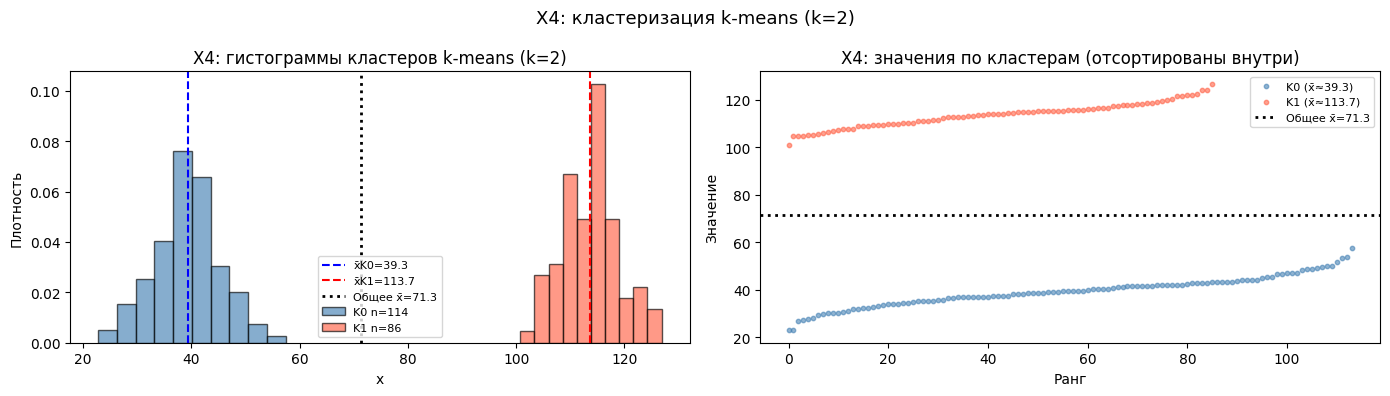

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограммы кластеров
ax = axes[0]
for clust, clr, lbl in [(c0,'steelblue',f'K0 n={sc0["n"]}'), (c1,'tomato',f'K1 n={sc1["n"]}')]:
    sc = sample_stats(clust)я 
    ivs, h = make_intervals(clust, 10)
    nc = sc['n']
    ax.bar([iv[0] for iv in ivs], [iv[3]/(nc*h) for iv in ivs],
           width=h, align='edge', color=clr, edgecolor='black', alpha=0.65, label=lbl)
ax.axvline(sc0['mean'], color='blue', ls='--', lw=1.5, label=f'x̄K0={sc0["mean"]:.1f}')
ax.axvline(sc1['mean'], color='red',  ls='--', lw=1.5, label=f'x̄K1={sc1["mean"]:.1f}')
ax.axvline(st4['mean'], color='black',ls=':',  lw=2,   label=f'Общее x̄={st4["mean"]:.1f}')
ax.set_title('X4: гистограммы кластеров k-means (k=2)')
ax.set_xlabel('x'); ax.set_ylabel('Плотность'); ax.legend(fontsize=8)

# Scatter: значения кластеров по индексу
ax2 = axes[1]
ax2.scatter(range(len(c0)), sorted(c0), color='steelblue', s=10, alpha=0.6,
            label=f'K0 (x̄≈{sc0["mean"]:.1f})')
ax2.scatter(range(len(c1)), sorted(c1), color='tomato', s=10, alpha=0.6,
            label=f'K1 (x̄≈{sc1["mean"]:.1f})')
ax2.axhline(st4['mean'], color='black', ls=':', lw=2, label=f'Общее x̄={st4["mean"]:.1f}')
ax2.set_title('X4: значения по кластерам (отсортированы внутри)')
ax2.set_xlabel('Ранг'); ax2.set_ylabel('Значение'); ax2.legend(fontsize=8)

plt.suptitle('X4: кластеризация k-means (k=2)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4.7 Итоговый вывод

**X1 - Нормальное N(a≈50.57, σ≈9.29).** Гистограмма симметрична; среднее≈медиана (50.57 и 50.34). Оценки MM и МП идентичны. Асимптотический ДИ для EX (95%): **(49.28; 51.86)**. Точный ДИ для µ: **(49.27; 51.87)**. ДИ для σ²: **(71.96; 106.70)**. Интервалы узкие - n=200 обеспечивает высокую точность.

**X2 - Равномерное U(a≈26.80, b≈72.57).** Прямоугольная гистограмма; линейная ЭФР. МП: â=26.80, b̂=72.57. MM: â=26.72, b̂=71.47. Расхождение P(X>x₀): |0.2050−0.2300|=0.0250 - допустимо. Асимптотический ДИ для EX (95%): **(47.31; 50.89)**.

**X3 - Экспоненциальное Exp(λ≈0.01744, c≈22.47).** Правосторонняя асимметрия; среднее (79.81)>>медиана (63.35). МП: ĉ=22.47, λ̂=0.01744. Расхождение P(X>x₀): |0.1350−0.1347|=0.0003 - модель отлично описывает данные. Асимптотический ДИ для EX (95%): **(71.83; 87.79)**.

**X4 - неоднородная выборка (бонус).** Бимодальная гистограмма. k-means (k=2): K₀ (n=114, x̄≈39.30, σ̂≈6.3) и K₁ (n=86, x̄≈113.71, σ̂≈7.9). Общее среднее (71.30) попадает в мёртвую зону и не несёт смысла - данные следует анализировать раздельно.